In [1]:
import sys
from pathlib import Path
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Set up paths
def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Embeddings:   {EMBEDDINGS_DIR}")
print(f"Checkpoints:  {CHECKPOINTS_DIR}")
print(f"Device:       {device}")

Project root: /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric
Embeddings:   /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/data/embeddings
Checkpoints:  /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints
Device:       mps


In [2]:
def load_embeddings(split):
    """Load a saved embeddings file. Returns (features, labels) tensors on CPU."""
    path = EMBEDDINGS_DIR / f"{split}_embeddings.pt"
    data = torch.load(path, weights_only=True)
    return data["features"], data["labels"]


train_features, train_labels = load_embeddings("train")
val_features, val_labels = load_embeddings("val")
heldout_features, heldout_labels = load_embeddings("heldout")

print(f"Train:    features {tuple(train_features.shape)}, labels {tuple(train_labels.shape)}")
print(f"Val:      features {tuple(val_features.shape)}, labels {tuple(val_labels.shape)}")
print(f"Held-out: features {tuple(heldout_features.shape)}, labels {tuple(heldout_labels.shape)}")
print(f"\nFeature dtype: {train_features.dtype}")
print(f"Label dtype:   {train_labels.dtype}")

# Sanity: every class appears in every split
print(f"\nUnique classes:")
print(f"  Train:    {len(torch.unique(train_labels))}")
print(f"  Val:      {len(torch.unique(val_labels))}")
print(f"  Held-out: {len(torch.unique(heldout_labels))}")

Train:    features (117000, 2048), labels (117000,)
Val:      features (13000, 2048), labels (13000,)
Held-out: features (5000, 2048), labels (5000,)

Feature dtype: torch.float32
Label dtype:   torch.int64

Unique classes:
  Train:    100
  Val:      100
  Held-out: 100


In [3]:
# Wrap (features, labels) pairs as TensorDatasets
train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
heldout_dataset = TensorDataset(heldout_features, heldout_labels)

# Build DataLoaders
# Larger batch size is fine here — we're just iterating over tensors in memory
BATCH_SIZE = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # SHUFFLE for training (important — gradient SGD relies on randomness)
    num_workers=0,          # data is already in memory; workers add overhead
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # eval doesn't need shuffling
    num_workers=0,
)

heldout_loader = DataLoader(
    heldout_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train batches:    {len(train_loader)}")
print(f"Val batches:      {len(val_loader)}")
print(f"Held-out batches: {len(heldout_loader)}")

Train batches:    229
Val batches:      26
Held-out batches: 10


In [4]:
# Pull one batch
features, labels = next(iter(train_loader))

print(f"Features batch shape: {features.shape}")
print(f"Features batch dtype: {features.dtype}")
print(f"Labels batch shape: {labels.shape}")
print(f"Labels batch dtype: {labels.dtype}")

print(f"\nFirst 10 labels: {labels[:10].tolist()}")
print(f"Feature stats: mean={features.mean():.4f}, std={features.std():.4f}, "
      f"min={features.min():.4f}, max={features.max():.4f}")

Features batch shape: torch.Size([512, 2048])
Features batch dtype: torch.float32
Labels batch shape: torch.Size([512])
Labels batch dtype: torch.int64

First 10 labels: [50, 88, 62, 41, 90, 69, 17, 96, 63, 3]
Feature stats: mean=0.0520, std=0.1104, min=0.0000, max=4.0106


In [5]:
class LinearClassifier(nn.Module):
    """
    Single linear layer mapping 2048-d Barlow Twins embeddings to 100 class logits.
    
    This is the simplest possible classification head — no nonlinearity, no asymmetry,
    no prototypes. It computes y = W @ x + b, where W has shape [100, 2048].
    
    Args:
        embed_dim: dimensionality of input features (2048 for Barlow Twins ResNet-50)
        n_classes: number of output classes (100 for ImageNet-100)
    """
    def __init__(self, embed_dim=2048, n_classes=100):
        super().__init__()
        self.fc = nn.Linear(embed_dim, n_classes)
    
    def forward(self, x):
        return self.fc(x)


# Instantiate and inspect
model = LinearClassifier(embed_dim=2048, n_classes=100).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model}")
print(f"\nTotal parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nWeight shape: {model.fc.weight.shape}")
print(f"Bias shape:   {model.fc.bias.shape}")

Model: LinearClassifier(
  (fc): Linear(in_features=2048, out_features=100, bias=True)
)

Total parameters: 204,900
Trainable parameters: 204,900

Weight shape: torch.Size([100, 2048])
Bias shape:   torch.Size([100])


In [6]:
# Forward pass on a batch to verify shapes
features, labels = next(iter(train_loader))
features = features.to(device)
labels = labels.to(device)

logits = model(features)

print(f"Input shape:  {features.shape}")
print(f"Output shape: {logits.shape}")
print(f"Output dtype: {logits.dtype}")
print(f"Output stats: mean={logits.mean():.4f}, std={logits.std():.4f}")
print(f"Random prediction accuracy: {(logits.argmax(dim=1) == labels).float().mean():.4f}")

Input shape:  torch.Size([512, 2048])
Output shape: torch.Size([512, 100])
Output dtype: torch.float32
Output stats: mean=-0.0025, std=0.0718
Random prediction accuracy: 0.0078


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Train for one epoch (one pass through the training data).
    
    Returns:
        avg_loss: average loss across the epoch (float)
        accuracy: classification accuracy across the epoch (float in [0, 1])
    """
    model.train()  # set model to training mode (matters for dropout/batchnorm; not for us yet, but good habit)
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        logits = model(features)
        loss = criterion(logits, labels)
        
        # Backward pass + optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


print("train_one_epoch defined.")

train_one_epoch defined.


In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a dataset (no gradient computation).
    
    Returns:
        avg_loss: average loss
        accuracy: top-1 accuracy
    """
    model.eval()  # eval mode (deterministic, no dropout)
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


print("evaluate defined.")

evaluate defined.


In [9]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, n_epochs):
    """
    Train the model for n_epochs, evaluating on val_loader after each epoch.
    
    Returns:
        history: dict with keys 'train_loss', 'train_acc', 'val_loss', 'val_acc',
                 each containing a list of per-epoch values
    """
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8} | {'Time':>6}")
    print("-" * 70)
    
    for epoch in range(1, n_epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        elapsed = time.time() - start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
              f"{val_loss:>9.4f} | {val_acc:>7.2%} | {elapsed:>5.1f}s")
    
    return history


print("fit defined.")

fit defined.


In [10]:
# Hyperparameters
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30

# Re-initialize the model fresh (in case we re-run this cell)
model = LinearClassifier(embed_dim=2048, n_classes=100).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(f"Optimizer: {optimizer}")
print(f"Loss: {criterion}")
print(f"Training for {N_EPOCHS} epochs")
print()

# Train!
history = fit(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=N_EPOCHS)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Loss: CrossEntropyLoss()
Training for 30 epochs

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |   Time
----------------------------------------------------------------------
    1 |     1.8574 |   75.66% |    0.9072 |  81.38% |   2.5s
    2 |     0.7477 |   83.55% |    0.6910 |  83.52% |   0.9s
    3 |     0.6125 |   85.33% |    0.6183 |  84.38% |   0.9s
    4 |     0.5533 |   86.49% |    0.5835 |  85.13% |   0.9s
    5 |     0.5180 |   87.15% |    0.5637 |  85.39% |   1.2s
    6 |     0.4948 |   87.66% |    0.5481 |  85.75% |   1.1s
    7 |     0.4779 |   88.06% |    0.5390 |  85.89% |   1.0s
    8 |     0.4645 |   88.43% |    0.5318 |  85.84% |   0.9s
    9 |     0.4545 |   88.69% |    0.5251 |  86.12% |   0.

In [11]:
# Save the model checkpoint
checkpoint_path = CHECKPOINTS_DIR / "linear_classifier.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "hyperparameters": {
        "embed_dim": 2048,
        "n_classes": 100,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
    },
    "final_metrics": {
        "train_loss": history["train_loss"][-1],
        "train_acc": history["train_acc"][-1],
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_epoch": history["val_acc"].index(max(history["val_acc"])) + 1,
    },
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")
print(f"Best val acc: {max(history['val_acc']):.4f} at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}")

Saved checkpoint to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints/linear_classifier.pt
Best val acc: 0.8658 at epoch 29


Matplotlib is building the font cache; this may take a moment.


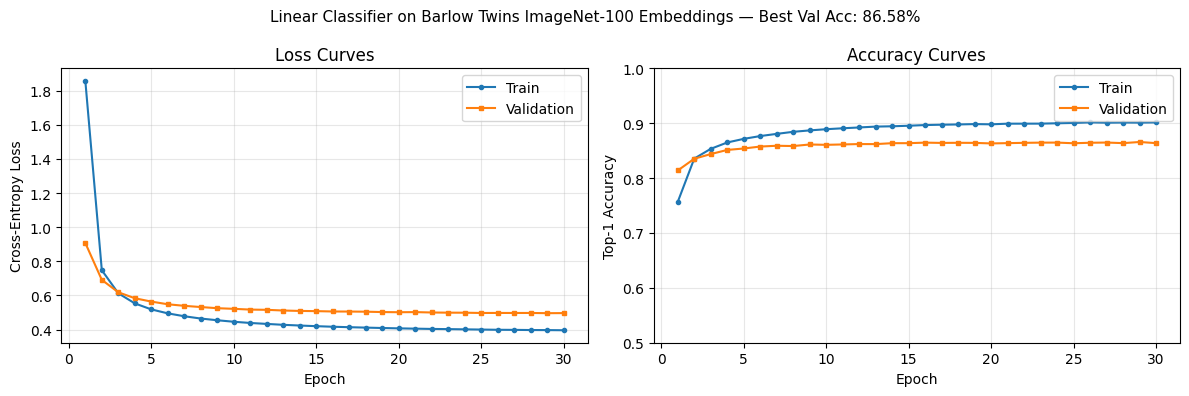

Saved plot to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/linear_classifier_curves.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs, history["val_loss"], label="Validation", marker="s", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs, history["val_acc"], label="Validation", marker="s", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Top-1 Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Linear Classifier on Barlow Twins ImageNet-100 Embeddings — "
             f"Best Val Acc: {max(history['val_acc']):.2%}", fontsize=11)
plt.tight_layout()

# Save the figure
plot_path = RESULTS_DIR / "linear_classifier_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")